In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
movies = pd.read_csv(r"./tmdb_5000_movies.csv")
credits = pd.read_csv(r"./tmdb_5000_credits.csv")

In [7]:
movies.head(3)

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466


In [8]:
credits.head(3)

,movie_id,title,cast,crew
0,19995,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,285,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,206647,Spectre,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."


In [9]:
movies.shape, credits.shape

((4803, 20), (4803, 4))

In [10]:
'''
Here Movie_id of "credits" dataframe is same as id of "movies" dataframe. Hence we can merge based on movie id
'''
credits_updated_df= credits.rename(columns={"movie_id":"id"})


In [11]:
credits_updated_df

,id,title,cast,crew
0,19995,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,285,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,206647,Spectre,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,49026,The Dark Knight Rises,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,49529,John Carter,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."
...,...,...,...,...
4798,9367,El Mariachi,"[{""cast_id"": 1, ""character"": ""El Mariachi"", ""c...","[{""credit_id"": ""52fe44eec3a36847f80b280b"", ""de..."
4799,72766,Newlyweds,"[{""cast_id"": 1, ""character"": ""Buzzy"", ""credit_...","[{""credit_id"": ""52fe487dc3a368484e0fb013"", ""de..."
4800,231617,"Signed, Sealed, Delivered","[{""cast_id"": 8, ""character"": ""Oliver O\u2019To...","[{""credit_id"": ""52fe4df3c3a36847f8275ecf"", ""de..."
4801,126186,Shanghai Calling,"[{""cast_id"": 3, ""character"": ""Sam"", ""credit_id...","[{""credit_id"": ""52fe4ad9c3a368484e16a36b"", ""de..."


In [12]:
movies.shape, credits_updated_df.shape


((4803, 20), (4803, 4))

In [13]:
movies_df_merge = movies.merge(credits_updated_df, on = "id")
movies_df_merge.shape

(4803, 23)

In [14]:
movies_df_merge.columns

Index(['budget', 'genres', 'homepage', 'id', 'keywords', 'original_language',
       'original_title', 'overview', 'popularity', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime',
       'spoken_languages', 'status', 'tagline', 'title_x', 'vote_average',
       'vote_count', 'title_y', 'cast', 'crew'],
      dtype='object')

In [15]:
movies_cleaned_df = movies_df_merge.drop(columns = ['homepage', 'title_x', 'title_y', 'status',
'production_countries'])

In [16]:
movies_cleaned_df.columns

Index(['budget', 'genres', 'id', 'keywords', 'original_language',
       'original_title', 'overview', 'popularity', 'production_companies',
       'release_date', 'revenue', 'runtime', 'spoken_languages', 'tagline',
       'vote_average', 'vote_count', 'cast', 'crew'],
      dtype='object')

## Computing Weighted Average Rating for each movie


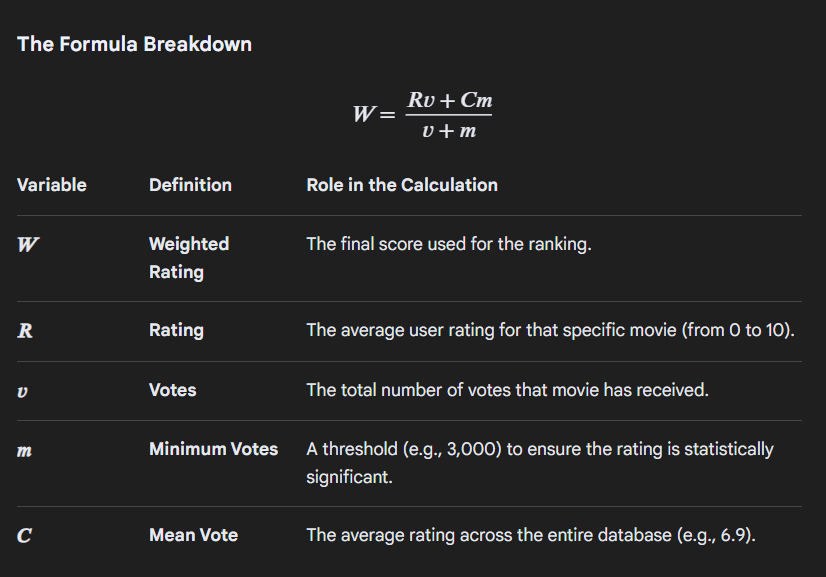

In [17]:

v = movies_cleaned_df['vote_count']
R = movies_cleaned_df ['vote_average']
C = movies_cleaned_df['vote_average'].mean()

In [18]:
print(C)

6.092171559442016


In [19]:
movies_cleaned_df[["original_title","vote_count"]]

,original_title,vote_count
0,Avatar,11800
1,Pirates of the Caribbean: At World's End,4500
2,Spectre,4466
3,The Dark Knight Rises,9106
4,John Carter,2124
...,...,...
4798,El Mariachi,238
4799,Newlyweds,5
4800,"Signed, Sealed, Delivered",6
4801,Shanghai Calling,7


<Axes: xlabel='vote_count'>

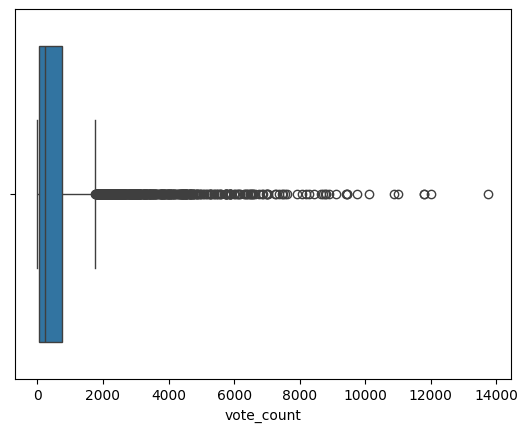

In [20]:
sns.boxplot(data=movies_cleaned_df, x="vote_count")

In [21]:
'''
Here we can keep m= 1900(threshold) based on box plot which shows vote count distribution with outliers
'''
threshold = movies_cleaned_df['vote_count'].quantile(q= 0.9)
threshold

np.float64(1838.4000000000015)

In [22]:
filtered_df = movies_cleaned_df[movies_cleaned_df['vote_count']>=threshold]
filtered_df

,budget,genres,id,keywords,original_language,original_title,overview,popularity,production_companies,release_date,revenue,runtime,spoken_languages,tagline,vote_average,vote_count,cast,crew
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Enter the World of Pandora.,7.2,11800,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]","At the end of the world, the adventure begins.",6.9,4500,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",A Plan No One Escapes,6.3,4466,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",The Legend Ends,7.6,9106,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]","Lost in our world, found in another.",6.1,2124,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4291,1200000,"[{""id"": 27, ""name"": ""Horror""}, {""id"": 9648, ""n...",176,"[{""id"": 1366, ""name"": ""shotgun""}, {""id"": 13000...",en,Saw,Obsessed with teaching his victims the value o...,63.655973,"[{""name"": ""Lions Gate Films"", ""id"": 35}, {""nam...",2004-10-01,103911669,103.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Live or die. Make your choice.,7.2,2184,"[{""cast_id"": 4, ""character"": ""Dr. Lawrence Gor...","[{""credit_id"": ""52fe4223c3a36847f8006c57"", ""de..."
4300,1200000,"[{""id"": 80, ""name"": ""Crime""}, {""id"": 53, ""name...",500,"[{""id"": 2052, ""name"": ""traitor""}, {""id"": 6099,...",en,Reservoir Dogs,A botched robbery indicates a police informant...,66.925866,"[{""name"": ""Live Entertainment"", ""id"": 285}, {""...",1992-09-02,14661007,99.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Every dog has his day.,8.0,3697,"[{""cast_id"": 20, ""character"": ""Mr. White/Larry...","[{""credit_id"": ""52fe424ac3a36847f8012cb9"", ""de..."
4302,1200000,"[{""id"": 37, ""name"": ""Western""}]",429,"[{""id"": 801, ""name"": ""bounty hunter""}, {""id"": ...",it,"Il buono, il brutto, il cattivo",Whi

In [23]:
m = threshold

In [24]:
R

0       7.2
1       6.9
2       6.3
3       7.6
4       6.1
       ... 
4798    6.6
4799    5.9
4800    7.0
4801    5.7
4802    6.3
Name: vote_average, Length: 4803, dtype: float64

In [25]:
v = filtered_df['vote_count']
R = filtered_df ['vote_average']
C = filtered_df['vote_average'].mean()

In [26]:
v

0       11800
1        4500
2        4466
3        9106
4        2124
        ...  
4291     2184
4300     3697
4302     2311
4337     2535
4602     2078
Name: vote_count, Length: 481, dtype: int64

In [27]:
filtered_df["weighted_avg"] = ((R*v)+(C*m))/(v+m)

C:\Users\monil\AppData\Local\Temp\ipykernel_18924\1453152412.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df["weighted_avg"] = ((R*v)+(C*m))/(v+m)


In [28]:
filtered_df.head()

,budget,genres,id,keywords,original_language,original_title,overview,popularity,production_companies,release_date,revenue,runtime,spoken_languages,tagline,vote_average,vote_count,cast,crew,weighted_avg
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Enter the World of Pandora.,7.2,11800,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de...",7.168053
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]","At the end of the world, the adventure begins.",6.9,4500,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de...",6.918271
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",A Plan No One Escapes,6.3,4466,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de...",6.493333
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",The Legend Ends,7.6,9106,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de...",7.492998
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]","Lost in our world, found in another.",6.1,2124,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de...",6.500396


In [29]:
filtered_df.columns

Index(['budget', 'genres', 'id', 'keywords', 'original_language',
       'original_title', 'overview', 'popularity', 'production_companies',
       'release_date', 'revenue', 'runtime', 'spoken_languages', 'tagline',
       'vote_average', 'vote_count', 'cast', 'crew', 'weighted_avg'],
      dtype='object')

In [30]:
df_sorted_ranking = filtered_df.sort_values(by="weighted_avg", ascending=False).head(20)

In [31]:
df_sorted_ranking[['original_title', 'vote_average', 'vote_count', 'weighted_avg', 'popularity']] # top 20 movies based on weighted average formula

,original_title,vote_average,vote_count,weighted_avg,popularity
1881,The Shawshank Redemption,8.5,8205,8.218658,136.747729
662,Fight Club,8.3,9413,8.081543,146.757391
3232,Pulp Fiction,8.3,8428,8.060583,121.463076
3337,The Godfather,8.4,5893,8.058304,143.659698
65,The Dark Knight,8.2,12002,8.035690,187.322927
809,Forrest Gump,8.2,7927,7.967126,138.133331
96,Inception,8.1,13752,7.965926,167.583710
95,Interstellar,8.1,10867,7.935482,724.247784
1990,The Empire Strikes Back,8.2,5879,7.905327,78.517830
1818,Schindler's List,8.3,4329,7.901461,104.469351


In [32]:
import warnings
from warnings import filterwarnings
filterwarnings("ignore")

<Axes: xlabel='weighted_avg', ylabel='original_title'>

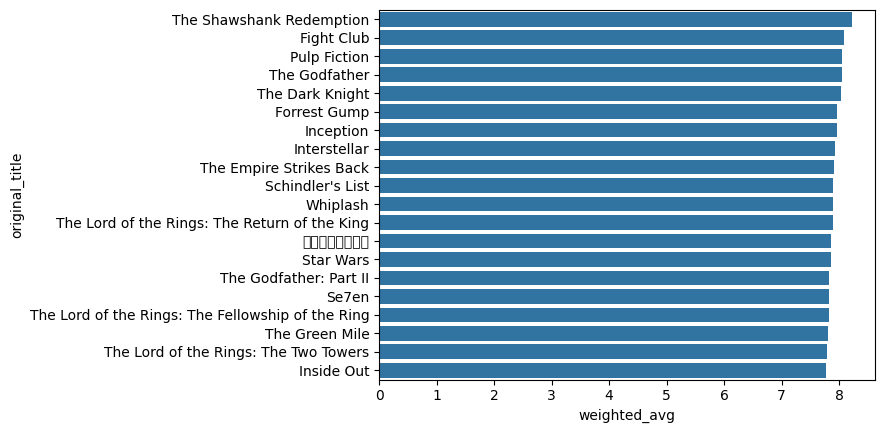

In [33]:
sns.barplot(x=df_sorted_ranking["weighted_avg"], y = df_sorted_ranking["original_title"])

In [34]:
filtered_df.columns

Index(['budget', 'genres', 'id', 'keywords', 'original_language',
       'original_title', 'overview', 'popularity', 'production_companies',
       'release_date', 'revenue', 'runtime', 'spoken_languages', 'tagline',
       'vote_average', 'vote_count', 'cast', 'crew', 'weighted_avg'],
      dtype='object')

In [35]:
popularity_df = filtered_df.sort_values(by="popularity", ascending = False)

In [36]:
popularity_df[['original_title','popularity']]

,original_title,popularity
546,Minions,875.581305
95,Interstellar,724.247784
788,Deadpool,514.569956
94,Guardians of the Galaxy,481.098624
127,Mad Max: Fury Road,434.278564
...,...,...
101,X-Men: First Class,3.195174
203,X2,2.871739
508,The Lost World: Jurassic Park,2.502487
2511,Home Alone,2.186927


In [37]:
popularity_df.set_index('original_title')['popularity'] [0:10] # top 10 movies based on popularity

original_title
Minions                                                   875.581305
Interstellar                                              724.247784
Deadpool                                                  514.569956
Guardians of the Galaxy                                   481.098624
Mad Max: Fury Road                                        434.278564
Jurassic World                                            418.708552
Pirates of the Caribbean: The Curse of the Black Pearl    271.972889
Dawn of the Planet of the Apes                            243.791743
The Hunger Games: Mockingjay - Part 1                     206.227151
Big Hero 6                                                203.734590
Name: popularity, dtype: float64

<Axes: ylabel='original_title'>

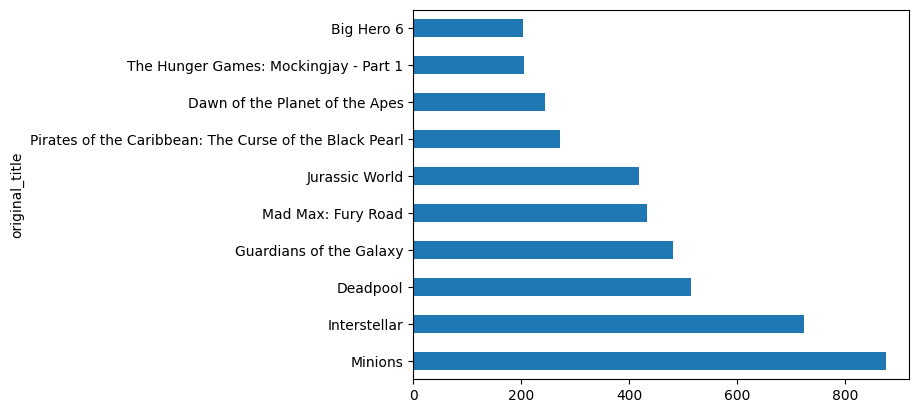

In [38]:
popularity_df.set_index('original_title')['popularity'][0:10].plot.barh()

In [39]:
filtered_df.shape, filtered_df.columns

((481, 19),
 Index(['budget', 'genres', 'id', 'keywords', 'original_language',
        'original_title', 'overview', 'popularity', 'production_companies',
        'release_date', 'revenue', 'runtime', 'spoken_languages', 'tagline',
        'vote_average', 'vote_count', 'cast', 'crew', 'weighted_avg'],
       dtype='object'))

In [40]:
from sklearn.preprocessing import MinMaxScaler

In [41]:
scaler = MinMaxScaler()

In [42]:
scaling_values = scaler.fit_transform(filtered_df[['weighted_avg','popularity']])

In [43]:
filtered_df[['weighted_avg_scaled', 'popularity_scaled']] = scaling_values

In [44]:
filtered_df.head(3)

,budget,genres,id,keywords,original_language,original_title,overview,popularity,production_companies,release_date,...,runtime,spoken_languages,tagline,vote_average,vote_count,cast,crew,weighted_avg,weighted_avg_scaled,popularity_scaled
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",2009-12-10,...,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Enter the World of Pandora.,7.2,11800,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de...",7.168053,0.607106,0.170052
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",2007-05-19,...,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]","At the end of the world, the adventure begins.",6.9,4500,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de...",6.918271,0.513695,0.157056
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",2015-10-26,...,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",A Plan No One Escapes,6.3,4466,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de...",6.493333,0.354781,0.120768


In [45]:
filtered_df.columns

Index(['budget', 'genres', 'id', 'keywords', 'original_language',
       'original_title', 'overview', 'popularity', 'production_companies',
       'release_date', 'revenue', 'runtime', 'spoken_languages', 'tagline',
       'vote_average', 'vote_count', 'cast', 'crew', 'weighted_avg',
       'weighted_avg_scaled', 'popularity_scaled'],
      dtype='object')

In [46]:
filtered_df['score_mix'] = filtered_df['weighted_avg_scaled'] * 0.5 + filtered_df['popularity_scaled'] * 0.5 # assigning 50 % weight to weighted average and 50% to popularity
filtered_df.head(4)

,budget,genres,id,keywords,original_language,original_title,overview,popularity,production_companies,release_date,...,spoken_languages,tagline,vote_average,vote_count,cast,crew,weighted_avg,weighted_avg_scaled,popularity_scaled,score_mix
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",2009-12-10,...,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Enter the World of Pandora.,7.2,11800,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de...",7.168053,0.607106,0.170052,0.388579
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",2007-05-19,...,"[{""iso_639_1"": ""en"", ""name"": ""English""}]","At the end of the world, the adventure begins.",6.9,4500,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de...",6.918271,0.513695,0.157056,0.335375
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",2015-10-26,...,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",A Plan No One Escapes,6.3,4466,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de...",6.493333,0.354781,0.120768,0.237774
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...",2012-07-16,...,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",The Legend Ends,7.6,9106,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de...",7.492998,0.728625,0.126417,0.427521


In [47]:
rank_df = filtered_df.sort_values(by='score_mix', ascending=False).head(10)

In [48]:
import plotly.express as px
import plotly.io as pio
pio.renderers.default = "notebook_connected"


In [49]:
px.bar(data_frame=rank_df, x='original_title', y ='score_mix')

## Building a content based recommendation system

In [50]:
data = filtered_df.copy()

In [51]:
data.columns

Index(['budget', 'genres', 'id', 'keywords', 'original_language',
       'original_title', 'overview', 'popularity', 'production_companies',
       'release_date', 'revenue', 'runtime', 'spoken_languages', 'tagline',
       'vote_average', 'vote_count', 'cast', 'crew', 'weighted_avg',
       'weighted_avg_scaled', 'popularity_scaled', 'score_mix'],
      dtype='object')

In [52]:
data['overview'][0]

'In the 22nd century, a paraplegic Marine is dispatched to the moon Pandora on a unique mission, but becomes torn between following orders and protecting an alien civilization.'

In [53]:
data['overview'].isnull().sum()

np.int64(0)

In [54]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [55]:
tfv = TfidfVectorizer(min_df=3, 
                max_features=None,
                ngram_range=(1,3),
                stop_words= "english")

In [56]:
tfv_matrix = tfv.fit_transform(data['overview'])

In [57]:
tfv_matrix

<481x1287 sparse matrix of type '<class 'numpy.float64'>'
	with 8196 stored elements in Compressed Sparse Row format>

In [58]:
tfv_matrix.shape

(481, 1287)

In [59]:
tfv_matrix.toarray()[0]

array([0., 0., 0., ..., 0., 0., 0.])

In [60]:
pd.DataFrame(tfv_matrix.toarray())

,0,1,2,3,4,5,6,7,8,9,...,1277,1278,1279,1280,1281,1282,1283,1284,1285,1286
0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
476,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
477,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
478,0.267267,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
479,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.25119,0.326234,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Finding Similarities between the summary or overview of movie using Sigmoid kernel 

In [61]:
from sklearn.metrics.pairwise import sigmoid_kernel

In [62]:
sig = sigmoid_kernel(tfv_matrix, tfv_matrix)

In [63]:
sig

array([[0.76192028, 0.76159416, 0.76159416, ..., 0.76159416, 0.76159416,
        0.76159416],
       [0.76159416, 0.76192028, 0.76159416, ..., 0.76159416, 0.76159416,
        0.76159416],
       [0.76159416, 0.76159416, 0.76192028, ..., 0.76159416, 0.76159416,
        0.76159416],
       ...,
       [0.76159416, 0.76159416, 0.76159416, ..., 0.76192028, 0.7616054 ,
        0.76161335],
       [0.76159416, 0.76159416, 0.76159416, ..., 0.7616054 , 0.76192028,
        0.76159416],
       [0.76159416, 0.76159416, 0.76159416, ..., 0.76161335, 0.76159416,
        0.76192028]])

In [64]:
pd.DataFrame(sig)

,0,1,2,3,4,5,6,7,8,9,...,471,472,473,474,475,476,477,478,479,480
0,0.761920,0.761594,0.761594,0.761612,0.761594,0.761609,0.761594,0.761619,0.761594,0.761594,...,0.761594,0.761594,0.761594,0.761594,0.761594,0.761594,0.761594,0.761594,0.761594,0.761594
1,0.761594,0.761920,0.761594,0.761594,0.761623,0.761594,0.761594,0.761609,0.761594,0.761594,...,0.761594,0.761594,0.761594,0.761594,0.761594,0.761604,0.761594,0.761594,0.761594,0.761594
2,0.761594,0.761594,0.761920,0.761594,0.761594,0.761594,0.761594,0.761608,0.761606,0.761594,...,0.761594,0.761594,0.761594,0.761594,0.761594,0.761594,0.761594,0.761594,0.761594,0.761594
3,0.761612,0.761594,0.761594,0.761920,0.761601,0.761597,0.761604,0.761606,0.761604,0.761680,...,0.761594,0.761594,0.761614,0.761603,0.761594,0.761594,0.761601,0.761594,0.761620,0.761594
4,0.761594,0.761623,0.761594,0.761601,0.761920,0.761594,0.761601,0.761618,0.761594,0.761606,...,0.761631,0.761594,0.761594,0.761594,0.761594,0.761610,0.761594,0.761603,0.761605,0.761594
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
476,0.761594,0.761604,0.761594,0.761594,0.761610,0.761594,0.761594,0.761594,0.761594,0.761594,...,0.761594,0.761594,0.761594,0.761594,0.761594,0.761920,0.761594,0.761594,0.761594,0.761594
477,0.761594,0.761594,0.761594,0.761601,0.761594,0.761594,0.761594,0.761594,0.761594,0.761594,...,0.761594,0.761594,0.761594,0.761594,0.761615,0.761594,0.761920,0.761594,0.761611,0.761594
478,0.761594,0.761594,0.761594,0.761594,0.761603,0.761607,0.761594,0.761594,0.761594,0.761602,...,0.761643,0.761594,0.761594,0.761594,0.761594,0.761594,0.761594,0.761920,0.761605,0.761613
479,0.761594,0.761594,0.761594,0.761620,0.761605,0.761600,0.761610,0.761610,0.761594,0.761621,...,0.761594,0.761594,0.761606,0.761594,0.761594,0.761594,0.761611,0.761605,0.761920,0.761594


In [65]:
data['original_title']

0                                         Avatar
1       Pirates of the Caribbean: At World's End
2                                        Spectre
3                          The Dark Knight Rises
4                                    John Carter
                          ...                   
4291                                         Saw
4300                              Reservoir Dogs
4302             Il buono, il brutto, il cattivo
4337                                 Taxi Driver
4602                                12 Angry Men
Name: original_title, Length: 481, dtype: object

In [66]:
data.index

Index([   0,    1,    2,    3,    4,    5,    6,    7,    8,    9,
       ...
       3865, 3887, 3895, 3940, 4259, 4291, 4300, 4302, 4337, 4602],
      dtype='int64', length=481)

In [67]:
indices = pd.Series(data=data.index, index=data['original_title'])

In [68]:
indices.head(4)

original_title
Avatar                                      0
Pirates of the Caribbean: At World's End    1
Spectre                                     2
The Dark Knight Rises                       3
dtype: int64

In [69]:
indices['Spectre']                                    

np.int64(2)

In [70]:
sig[indices['Spectre']][:5]

array([0.76159416, 0.76159416, 0.76192028, 0.76159416, 0.76159416])

In [71]:
list(enumerate(sig[indices['Spectre']]))

[(0, np.float64(0.7615941559557649)),
 (1, np.float64(0.7615941559557649)),
 (2, np.float64(0.7619202832910207)),
 (3, np.float64(0.7615941559557649)),
 (4, np.float64(0.7615941559557649)),
 (5, np.float64(0.7615941559557649)),
 (6, np.float64(0.7615941559557649)),
 (7, np.float64(0.7616084035653704)),
 (8, np.float64(0.7616064041524085)),
 (9, np.float64(0.7615941559557649)),
 (10, np.float64(0.7617086705506222)),
 (11, np.float64(0.7615941559557649)),
 (12, np.float64(0.7615941559557649)),
 (13, np.float64(0.7615941559557649)),
 (14, np.float64(0.7615941559557649)),
 (15, np.float64(0.7616221017805211)),
 (16, np.float64(0.7616079851416016)),
 (17, np.float64(0.7615941559557649)),
 (18, np.float64(0.7615941559557649)),
 (19, np.float64(0.7615941559557649)),
 (20, np.float64(0.7615941559557649)),
 (21, np.float64(0.7615941559557649)),
 (22, np.float64(0.7615941559557649)),
 (23, np.float64(0.7615941559557649)),
 (24, np.float64(0.7615941559557649)),
 (25, np.float64(0.7616905081775185

In [72]:
sigma = sorted(list(enumerate(sig[indices['Spectre']])), key= lambda x : x[1], reverse=True)

In [73]:
sigma[0:10]

[(2, np.float64(0.7619202832910207)),
 (10, np.float64(0.7617086705506222)),
 (25, np.float64(0.7616905081775185)),
 (185, np.float64(0.7616738032821158)),
 (74, np.float64(0.7616441660221615)),
 (263, np.float64(0.7616358593933314)),
 (155, np.float64(0.7616358491591899)),
 (111, np.float64(0.7616340569826029)),
 (284, np.float64(0.7616336157443014)),
 (367, np.float64(0.7616291828679765))]

In [74]:
ind = [ i[0] for i in sigma[0:10] ] 

In [75]:
ind

[2, 10, 25, 185, 74, 263, 155, 111, 284, 367]

In [76]:
dataframe = data.reset_index()

In [77]:
dataframe['original_title'][ind] # TOp 10 recommendation for person watching moviie "Spectre"

2                             Spectre
10                  Quantum of Solace
25                            Skyfall
185                     Casino Royale
74                         Big Hero 6
263                Olympus Has Fallen
155                      Jason Bourne
111                  White House Down
284    Maze Runner: The Scorch Trials
367            The Cabin in the Woods
Name: original_title, dtype: object

## Auomating ML model using Function

In [78]:
def give_recommendations(movie_title , model):
    
    indices = pd.Series(data = data.index , index= data['original_title'])
    
    idx = indices[movie_title]
    
    model_scores = list(enumerate(model[idx]))
    
    model_scores_sorted = sorted(model_scores , key= lambda x : x[1] , reverse = True)
    
    model_scores_10 = model_scores_sorted[1:11]
    
    movie_indices_10 = [i[0] for i in model_scores_10 ]
    
    return dataframe['original_title'][movie_indices_10]

In [79]:
import joblib

In [80]:
'''
Dumping two model and two dataframe for using it in web application
'''
data.to_csv(r"./dumped_obj/movie_data_for_app.csv", index=False)
dataframe.to_csv(r"./dumped_obj/movie_dataframe_for_app.csv", index=False)
joblib.dump(tfv, r"./dumped_obj/tfidf_vectorizer.pkl")
joblib.dump(sig, r"./dumped_obj/sigmoid_kernel.pkl")

['./dumped_obj/sigmoid_kernel.pkl']